In [51]:
import torch
import torchvision.models as models
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Ready to train on: {device}")

Ready to train on: cuda


In [54]:
import kagglehub

print("Downloading Data....")
# الكود ده هيحمل الداتا مباشرة من كاجل لسيرفر Lightning
path = kagglehub.dataset_download("nih-chest-xrays/data")

print("Succefully Downloaded!")
print("The new path : ", path)

Succefully Downloaded!
The new path :  /teamspace/studios/this_studio/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3


In [6]:
dataset_main_path = '/teamspace/studios/this_studio/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3'

import os
csv_path = ''
test_list_path = ''
for root, dirs, files in os.walk(dataset_main_path):
        if 'Data_Entry_2017.csv' in files:
            csv_path = os.path.join(root, 'Data_Entry_2017.csv')
        if 'test_list.txt' in files:
            test_list_path = os.path.join(root, 'test_list.txt')
print('Done loading ')
print(f"csv_path : {csv_path}")
print(f"test_list_path : {test_list_path}")

Done loading 
csv_path : /teamspace/studios/this_studio/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/Data_Entry_2017.csv
test_list_path : /teamspace/studios/this_studio/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/test_list.txt


In [ ]:
from PIL import Image
import torchvision.transforms as transforms
class ChestXRaysDataset(Dataset):
    def __init__(self, data_df, dataset_path, transform = None):
        self.df = data_df
        self.transform = transform

        self.classes = [
            'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 
            'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 
            'Fibrosis', 'Pleural_Thickening', 'Hernia'
        ]
        self.image_path = {}
        for root, dirs, files in os.walk(dataset_path):
            for file in files:
                if file.endswith('.png'):
                    self.image_path[file] = os.path.join(root, file)

        print(f"Dataset is initialized Correctly with length {len(self.df)}")
        
    
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.df.iloc[idx]['Image Index']
        image_path = self.image_path[image_name]   
        image = Image.open(image_path).convert('RGB')
        self.labels = []
        labels_str = self.df.iloc[idx]['Finding Labels']
        labels_vector = torch.zeros(len(self.classes))
        for i, disease in enumerate(self.classes):
            if disease in labels_str:
                labels_vector[i] = 1.0

        if self.transform is not None:
            image = self.transform(image)

        return image, labels_vector
        
    

In [8]:
from sklearn.model_selection import train_test_split
import pandas as pd
def split_data(csv_path, test_list_path):
    df_data = pd.read_csv(csv_path)

    unique_patients = df_data['Patient ID'].unique()

    train_patients, val_patients = train_test_split(unique_patients, test_size = .2, random_state = 42)

    train_df = df_data[df_data['Patient ID'].isin(train_patients)].reset_index(drop = True)
    val_df = df_data[df_data['Patient ID'].isin(val_patients)].reset_index(drop = True)

    with open(test_list_path, 'r') as f:
        test_images = f.read().splitlines()

    print(f"Found {len(test_images)} images to test")

    test_df = df_data[df_data['Image Index'].isin(test_images)].reset_index(drop = True)
    

    return train_df, val_df, test_df

In [9]:



class ChexNet(nn.Module):
    def __init__(self, out_size):
        super(ChexNet, self).__init__()

        self.denseNet = models.densenet121(weights = models.DenseNet121_Weights.DEFAULT)
        num_filters = self.denseNet.classifier.in_features
        self.denseNet.classifier = nn.Sequential(nn.Linear(num_filters, out_size))
    
    def forward(self,x):
        return self.denseNet(x)

        



In [ ]:
n_classes = 14
batch_size = 16
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.optim as optim
import gc

def epoch_train(model,train_loader,loss_function, optimizer):
    model.train()
    total_loss = 0.0
    
    for image, label in train_loader:
        image = image.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        output = model(image)
        loss = loss_function(output, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(train_loader)

def epoch_val(model, val_loader, loss_function):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for image, label in val_loader:
            image = image.to(device)
            label = label.to(device)
            output = model(image)
            loss = loss_function(output, label)
            total_loss += loss.item()
    return total_loss / len(val_loader)
            

def train(n_classes, batch_size, model_name, train_df, val_df, lr, num_epochs):
    if model_name == 'ChexNet':
        model = ChexNet(n_classes).to(device)
        model = torch.nn.DataParallel(model).to(device)

    train_transforms = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomRotation(degrees = 15),
        transforms.RandomHorizontalFlip(p=.5),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )
    ])

    val_transforms = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )
        
    ])

    dataset_train = ChestXRaysDataset(train_df, dataset_main_path, train_transforms)
    dataset_val = ChestXRaysDataset(val_df, dataset_main_path, val_transforms)

    dataloader_train = DataLoader(dataset_train, shuffle = True, batch_size = batch_size, num_workers=2)
    dataloader_val = DataLoader(dataset_val, shuffle = False, batch_size = batch_size, num_workers=2)

    optimizer = optim.AdamW(lr = lr, params = model.parameters())
    loss = nn.BCEWithLogitsLoss()

    schedular = ReduceLROnPlateau(factor = .1, optimizer = optimizer, patience = 2, mode = "min")
    

    CHECKPOINT_PATH = "chexnet_checkpoint.pth"
    start_epoch = 0
    best_val_loss = float("inf")

    if os.path.exists(CHECKPOINT_PATH):
        print('Found an existing model...')
        checkpoint = torch.load(CHECKPOINT_PATH, map_location = device)

        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        schedular.load_state_dict(checkpoint['schedular_state'])

        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        print('Model is reloaded Succesfully!')
    else:
        print('No Checkpoints exists, Starting Training...')

    for epoch in range(start_epoch, num_epochs):
        train_loss = epoch_train(model,dataloader_train,loss, optimizer)
        val_loss = epoch_val(model, dataloader_val, loss)

        schedular.step(val_loss)

        checkpoint = {
            'epoch' : epoch,
            'model_state' : model.state_dict(),
            'optimizer_state' : optimizer.state_dict(),
            'schedular_state' : schedular.state_dict(),
            'best_val_loss' : best_val_loss 
        }
        torch.save(checkpoint, CHECKPOINT_PATH)
        if val_loss <= best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("New best model saved!")
        print(f"[----] Epoch {epoch+1} Train={train_loss:.4f} Val={val_loss:.4f}")
    

        


    
   

    


In [24]:
def test_model(model_path, test_df, num_classes, batch_size):
    checkpoint = torch.load(model_path, map_location = device)
    model = ChexNet(num_classes).to(device)
    model = nn.DataParallel(model)
    model.load_state_dict(checkpoint)
    model.eval()

    prediction = []
    ground_truth = []

    test_trasforms = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )
        
    ])
    
    dataset_test = ChestXRaysDataset(test_df, dataset_main_path, test_trasforms)
    dataloader_test = DataLoader(dataset_test, shuffle = True, batch_size = batch_size, num_workers=2)
    

    with torch.no_grad():
        for image, labels in dataloader_test:
            image = image.to(device)
            labels = labels.to(device)

            output = model(image)
            propa = torch.sigmoid(output)
            
            prediction.append(propa.cpu())
            ground_truth.append(labels.cpu())

    final_pred = torch.cat(prediction, dim =0)
    final_ground_truth = torch.cat(ground_truth, dim =0)

    return final_pred, final_ground_truth
            

In [26]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np
def AUC(predictions, ground_truth, num_classes, classes_names):
    pred = predictions.numpy()
    gt = ground_truth.numpy()

    aucroc_scores = []

    for i in range(num_classes):
        p = pred[:,i]
        y = gt[:,i]
        disease_name = classes_names[i]
        scores = roc_auc_score(y, p)
        aucroc_scores.append(scores)
        print(f"AUC-ROC for {disease_name} : {scores}")

    avg_scores = np.mean(aucroc_scores)
    print(f"Average AUC-ROC is {avg_scores}")

    return avg_scores
    

In [13]:
def F1_Score(predictions, ground_truth, num_classes, threshold = .5):
    pred = predictions.numpy()
    gt = ground_truth.numpy()

    threshold_pred = (threshold <= pred).astype(int)

    f1_scores = []
    for i in range(num_classes):
        p = pred[:,i]
        y = gt[:,i]
        tp = threshold_pred[:,i]

        f1 = f1_score(y, tp)
        f1_scores.append(f1)
    avg_f1 = np.mean(f1_scores)
    
    print(f"Average F1 Scores is {avg_f1}")
    return avg_f1
    

In [ ]:

if __name__ == '__main__':

    
    train_df, val_df, test_df = split_data(csv_path, test_list_path)
    train(n_classes = 14,
          batch_size = 32,
          model_name = 'ChexNet',
          train_df = train_df,
          val_df = val_df,
          lr = .001,
          num_epochs = 20)
    
    print('We are Done!!!!!!!')
  
    

Found 25596 images to test
Dataset is initialized Correctly with length 89826
Dataset is initialized Correctly with length 22294
Found an existing model...
Model is reloaded Succesfully!
New best model saved!
[----] Epoch 14 Train=0.1463 Val=0.1524
New best model saved!
[----] Epoch 15 Train=0.1453 Val=0.1509
[----] Epoch 16 Train=0.1448 Val=0.1523
[----] Epoch 17 Train=0.1441 Val=0.1513
[----] Epoch 18 Train=0.1437 Val=0.1522
New best model saved!
[----] Epoch 19 Train=0.1390 Val=0.1490
[----] Epoch 20 Train=0.1378 Val=0.1491
We are Done!!!!!!!


In [27]:
if __name__ == '__main__': 
    model_path = 'best_model.pth'
    classes_names = [
        'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 
            'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 
            'Fibrosis', 'Pleural_Thickening', 'Hernia'
    ]
    final_pred, final_ground_truth = test_model(model_path = model_path,
               test_df = test_df, num_classes=14, batch_size = 32)
    
    final_pred_1 = final_pred
    final_g_t_1 = final_ground_truth

    avg_auc_scores = AUC(final_pred_1, final_g_t_1, 14, classes_names=classes_names)
    # avg_f1 = F1_Score(final_pred, final_ground_truth, 14)

Dataset is initialized Correctly with length 25596
AUC-ROC for Atelectasis : 0.7999905107370313
AUC-ROC for Cardiomegaly : 0.9230409792945772
AUC-ROC for Effusion : 0.8534383198698106
AUC-ROC for Infiltration : 0.7304453803751983
AUC-ROC for Mass : 0.8718415285749488
AUC-ROC for Nodule : 0.7966480903668094
AUC-ROC for Pneumonia : 0.7702311272576039
AUC-ROC for Pneumothorax : 0.9055999632800024
AUC-ROC for Consolidation : 0.7904981092969211
AUC-ROC for Edema : 0.8806592925055898
AUC-ROC for Emphysema : 0.9292161472917837
AUC-ROC for Fibrosis : 0.8691797696398413
AUC-ROC for Pleural_Thickening : 0.815372314750682
AUC-ROC for Hernia : 0.9673552551211109
Average AUC-ROC is 0.850251199168708


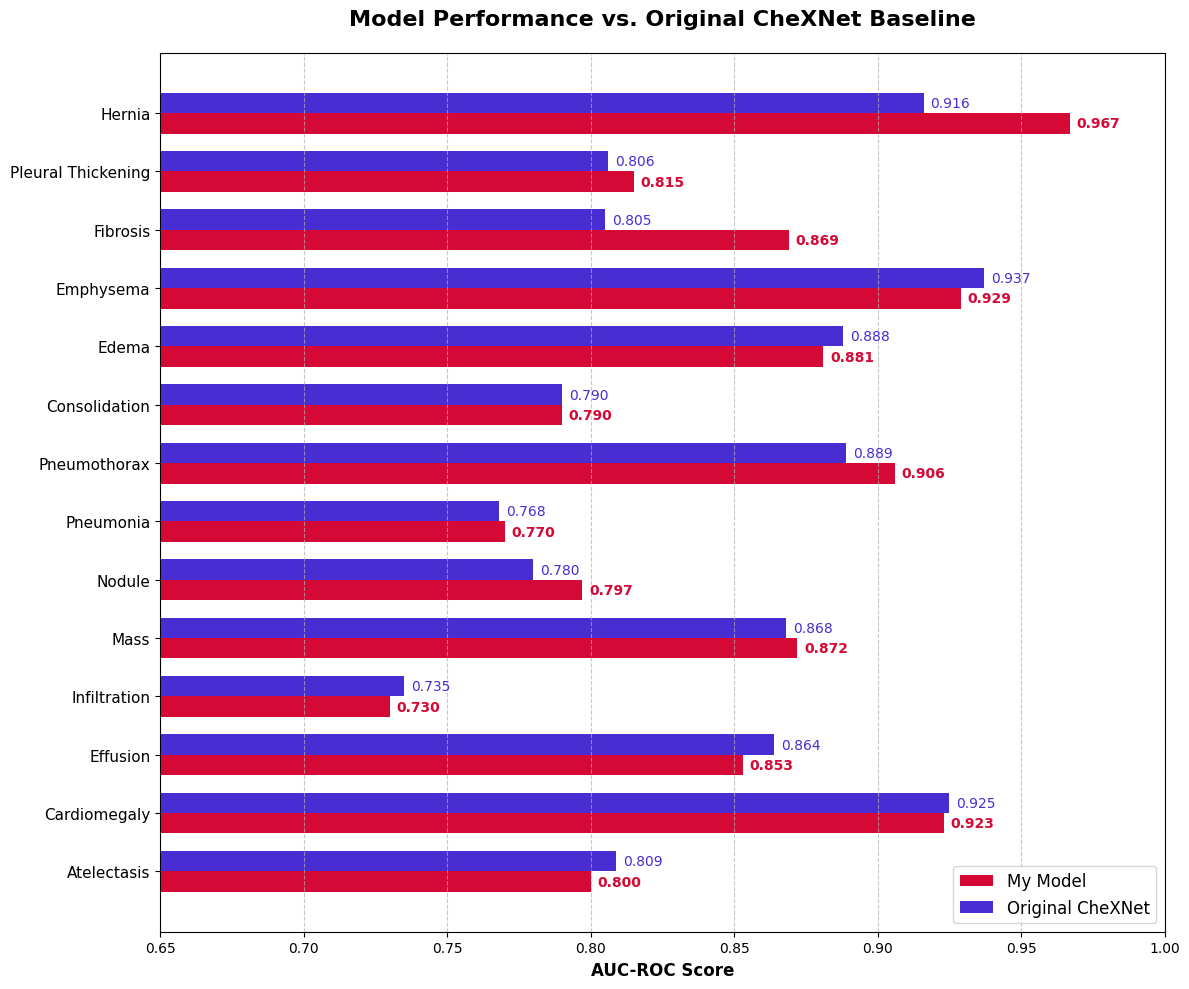

Succefully saved in :chexnet_comparison_results.png


In [55]:
import matplotlib.pyplot as plt
import numpy as np

pathologies = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 
               'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 
               'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 
               'Pleural Thickening', 'Hernia']

user_scores = [0.800, 0.923, 0.853, 0.730, 0.872, 0.797, 0.770, 0.906, 0.790, 0.881, 0.929, 0.869, 0.815, 0.967]
paper_scores = [0.809, 0.925, 0.864, 0.735, 0.868, 0.780, 0.768, 0.889, 0.790, 0.888, 0.937, 0.805, 0.806, 0.916]

y = np.arange(len(pathologies))  
height = 0.35  

fig, ax = plt.subplots(figsize=(12, 10))

rects1 = ax.barh(y - height/2, user_scores, height, label='My Model', color="#d50935") 
rects2 = ax.barh(y + height/2, paper_scores, height, label='Original CheXNet', color='#482dd3') 

ax.set_xlabel('AUC-ROC Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance vs. Original CheXNet Baseline', fontsize=16, fontweight='bold', pad=20)
ax.set_yticks(y)
ax.set_yticklabels(pathologies, fontsize=11)
ax.legend(fontsize=12, loc='lower right')

ax.grid(axis='x', linestyle='--', alpha=0.7)

ax.set_xlim(0.65, 1.0)

ax.bar_label(rects1, fmt='%.3f', padding=5, fontsize=10, fontweight='bold', color="#d50935")
ax.bar_label(rects2, fmt='%.3f', padding=5, fontsize=10, color="#482dd3")

fig.tight_layout()
plt.savefig('chexnet_comparison_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Succefully saved in :chexnet_comparison_results.png")

In [56]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torchvision.transforms as transforms

# 1. Grad-CAM Class to extract the magic from your model
class GradCam:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class):
        self.model.eval()
        model_output = self.model(input_tensor)
        self.model.zero_grad()
        
        target = model_output[0][target_class]
        target.backward()

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        for i in range(activations.size(0)):
            activations[i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=0).squeeze().cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
        return heatmap

def show_cam_on_image(img_path, heatmap, save_path="gradcam_result.png"):
    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, (224, 224))
    original_img = np.float32(original_img) / 255.0

    heatmap = cv2.resize(heatmap, (224, 224))
    
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = np.float32(heatmap_colored) / 255.0
    
    overlay = heatmap_colored * 0.4 + original_img * 0.6
    overlay = overlay / np.max(overlay) # Re-normalize
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_img[:, :, ::-1])
    axes[0].set_title('Original X-Ray', fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(overlay[:, :, ::-1])
    axes[1].set_title('Grad-CAM Heatmap', fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved successfully as: {save_path}")

In [58]:
import os

disease_name = 'Pneumonia' 

try:
    sample_row = test_df[test_df[disease_name] == 1].iloc[0]
except KeyError:
    sample_row = test_df[test_df['Finding Labels'].str.contains(disease_name)].iloc[0]

image_name = sample_row['Image Index'] 


base_dataset_path = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/" 

print(f"Searching... {image_name} in folders...")

exact_image_path = None
for root, dirs, files in os.walk(base_dataset_path):
    if image_name in files:
        exact_image_path = os.path.join(root, image_name)
        break

if exact_image_path:
    print("=" * 60)
    print(f"image_path = '{exact_image_path}'")
    print("=" * 60)
else:
    print("\n Didn't find the image!!!!")

Searching... 00000013_010.png in folders...
image_path = '/teamspace/studios/this_studio/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_001/images/00000013_010.png'


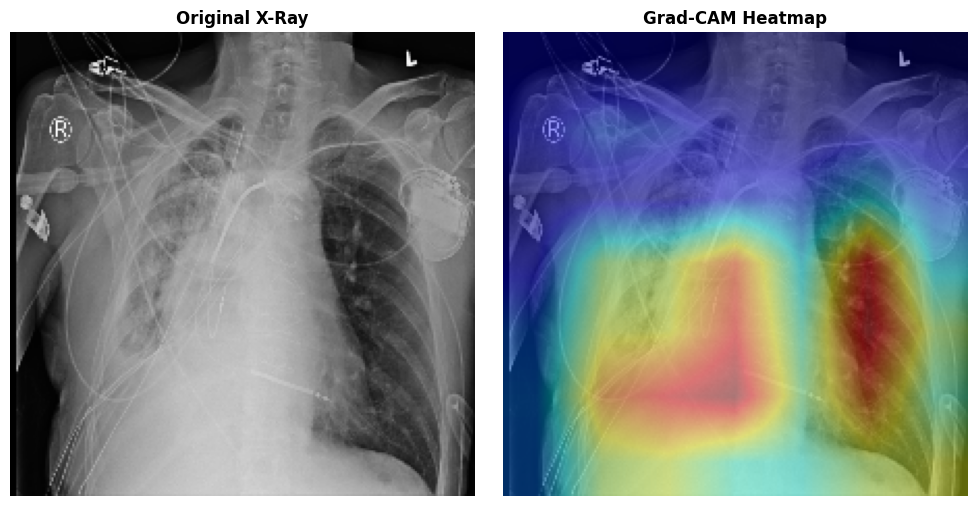

Saved successfully as: Cardiomegaly_gradcam.png


In [59]:


if __name__ == '__main__':

    checkpoint = torch.load(model_path, map_location = device)
    model = ChexNet(14).to(device)
    model = nn.DataParallel(model)
    model.load_state_dict(checkpoint)

    target_layer = model.module.denseNet.features.denseblock4.denselayer16.conv2

    cam = GradCam(model=model, target_layer=target_layer)


    image_path = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_001/images/00000013_010.png"

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    image_pil = Image.open(image_path).convert('RGB')
    input_tensor = transform(image_pil).unsqueeze(0).to(device)


    target_class_index = pathologies.index(disease_name)

    heatmap = cam.generate(input_tensor, target_class=target_class_index)

    # Overlay and Save!
    show_cam_on_image(image_path, heatmap, save_path="Cardiomegaly_gradcam.png")

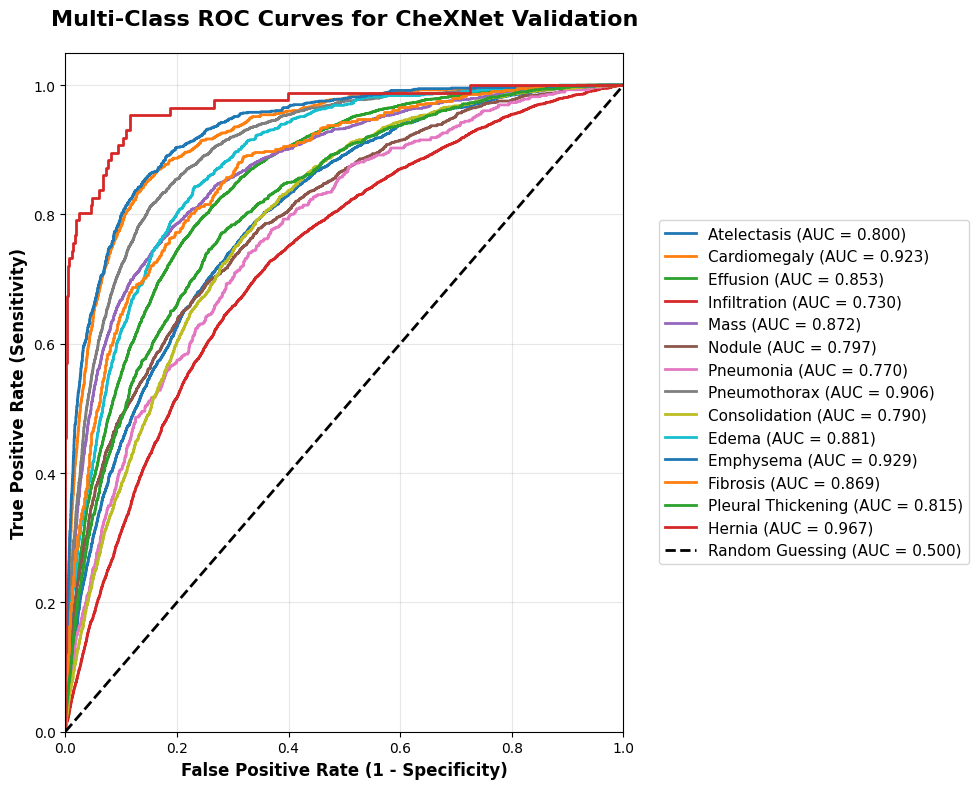

ROC curves saved succesfully in : chexnet_roc_curves.png


In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

pathologies = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 
               'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 
               'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 
               'Pleural Thickening', 'Hernia']

plt.figure(figsize=(10, 8))

if torch.is_tensor(final_ground_truth):
    final_ground_truth = final_ground_truth.cpu().numpy()
if torch.is_tensor(final_pred):
    final_pred = final_pred.cpu().numpy()

for i in range(14):
    fpr, tpr, thresholds = roc_curve(final_ground_truth[:, i], final_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{pathologies[i]} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Guessing (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('Multi-Class ROC Curves for CheXNet Validation', fontsize=16, fontweight='bold', pad=20)

plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chexnet_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC curves saved succesfully in : chexnet_roc_curves.png")
